loading annotations into memory...
Done (t=1.08s)
creating index...
index created!


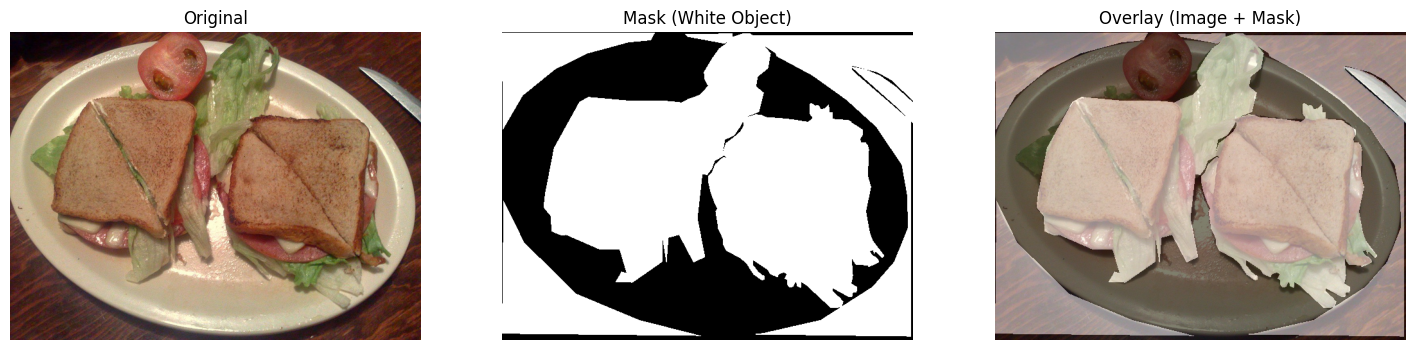

In [1]:
import cv2
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import os, random
import numpy as np

# Dataset path in Kaggle
data_dir = '/kaggle/input/coco-2017-dataset/coco2017'
img_dir = os.path.join(data_dir, 'val2017')  # using validation set
ann_path = os.path.join(data_dir, 'annotations/instances_val2017.json')

# Initialize COCO object
coco = COCO(ann_path)

# Select a random image
img_id = random.choice(coco.getImgIds())
img_info = coco.loadImgs(img_id)[0]

# Load the image
image = cv2.imread(os.path.join(img_dir, img_info['file_name']))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get annotations for the image
ann_ids = coco.getAnnIds(imgIds=img_id)
anns = coco.loadAnns(ann_ids)

# Initialize empty mask (all black)
mask_total = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

# Combine all object masks in the image
for ann in anns:
    mask_total = np.maximum(mask_total, coco.annToMask(ann))

# Convert to binary: object = 255 (white), background = 0 (black)
binary_mask = (mask_total * 255).astype(np.uint8)

plt.figure(figsize=(18,6))

# 1. Original
plt.subplot(1,3,1)
plt.imshow(image)
plt.axis('off')
plt.title('Original')

# 2. Mask only (object white, background black)
plt.subplot(1,3,2)
plt.imshow(binary_mask, cmap='gray')
plt.axis('off')
plt.title('Mask (White Object)')

# 3. Overlay: Image + Mask (semi-transparent)
plt.subplot(1,3,3)
plt.imshow(image)
plt.imshow(binary_mask, alpha=0.5, cmap='gray')
plt.axis('off')
plt.title('Overlay (Image + Mask)')

plt.show()




loading annotations into memory...
Done (t=0.78s)
creating index...
index created!


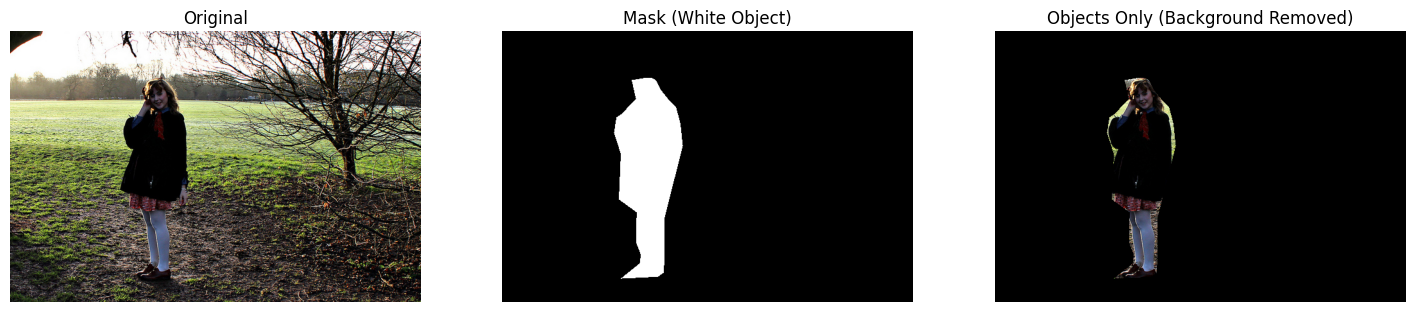

In [2]:
import cv2
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import os, random
import numpy as np

# Dataset path in Kaggle
data_dir = '/kaggle/input/coco-2017-dataset/coco2017'
img_dir = os.path.join(data_dir, 'val2017')
ann_path = os.path.join(data_dir, 'annotations/instances_val2017.json')

# Initialize COCO object
coco = COCO(ann_path)

# Select a random image
img_id = random.choice(coco.getImgIds())
img_info = coco.loadImgs(img_id)[0]

# Load the image
image = cv2.imread(os.path.join(img_dir, img_info['file_name']))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get annotations for the image
ann_ids = coco.getAnnIds(imgIds=img_id)
anns = coco.loadAnns(ann_ids)

# Initialize empty mask (all black)
mask_total = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

# Combine all object masks in the image
for ann in anns:
    mask_total = np.maximum(mask_total, coco.annToMask(ann))

# Convert to binary: object = 255 (white), background = 0 (black)
binary_mask = (mask_total * 255).astype(np.uint8)
mask_3_channel = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2BGR)

# Perform element-wise multiplication
result = cv2.bitwise_and(image, mask_3_channel)

plt.figure(figsize=(18,6))

# 1. Original
plt.subplot(1,3,1)
plt.imshow(image)
plt.axis('off')
plt.title('Original')

# 2. Mask only (object white, background black)
plt.subplot(1,3,2)
plt.imshow(binary_mask, cmap='gray')
plt.axis('off')
plt.title('Mask (White Object)')

# 3. Only the masked objects
plt.subplot(1,3,3)
plt.imshow(result)
plt.axis('off')
plt.title('Objects Only (Background Removed)')

plt.show()

loading annotations into memory...
Done (t=1.01s)
creating index...
index created!


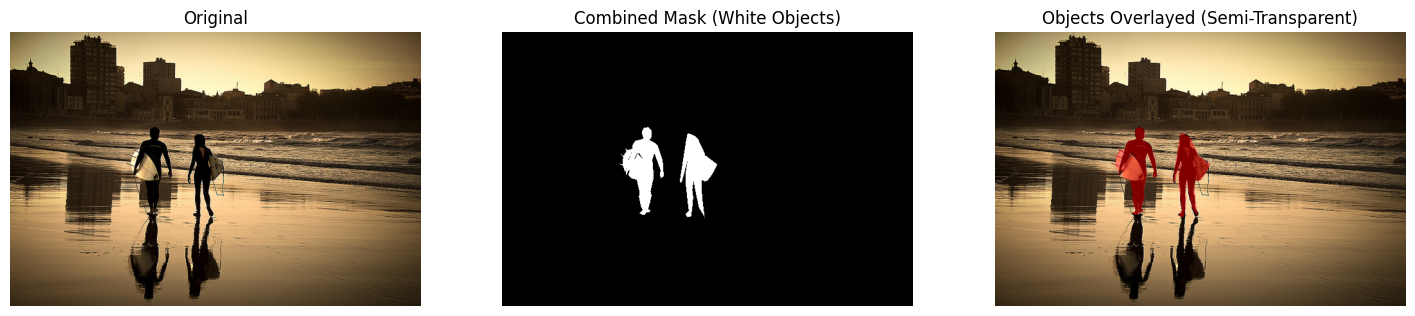

In [3]:
import cv2
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import os, random
import numpy as np

# Dataset path in Kaggle
data_dir = '/kaggle/input/coco-2017-dataset/coco2017'
img_dir = os.path.join(data_dir, 'val2017')
ann_path = os.path.join(data_dir, 'annotations/instances_val2017.json')

# Initialize COCO object
coco = COCO(ann_path)

# Select a random image
img_id = random.choice(coco.getImgIds())
img_info = coco.loadImgs(img_id)[0]

# Load the image
image = cv2.imread(os.path.join(img_dir, img_info['file_name']))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get annotations for the image
ann_ids = coco.getAnnIds(imgIds=img_id)
anns = coco.loadAnns(ann_ids)

# Initialize empty mask (all black)
mask_total = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

# Combine all object masks in the image
for ann in anns:
    mask_total = np.maximum(mask_total, coco.annToMask(ann))

# Convert to binary: object = 255 (white), background = 0 (black)
binary_mask = (mask_total * 255).astype(np.uint8)

# Create semi-transparent overlay
overlay = image.copy()
color = (255, 0, 0)  # Red overlay for objects
overlay[mask_total == 1] = color

# Blend overlay with original image
alpha = 0.5  # Transparency factor
overlayed = cv2.addWeighted(image, 1 - alpha, overlay, alpha, 0)

# =========================
# Plot results
# =========================
plt.figure(figsize=(18,6))

# 1. Original
plt.subplot(1,3,1)
plt.imshow(image)
plt.axis('off')
plt.title('Original')

# 2. Mask only (objects combined)
plt.subplot(1,3,2)
plt.imshow(binary_mask, cmap='gray')
plt.axis('off')
plt.title('Combined Mask (White Objects)')

# 3. Original + Overlay
plt.subplot(1,3,3)
plt.imshow(overlayed)
plt.axis('off')
plt.title('Objects Overlayed (Semi-Transparent)')

plt.show()


loading annotations into memory...
Done (t=1.09s)
creating index...
index created!


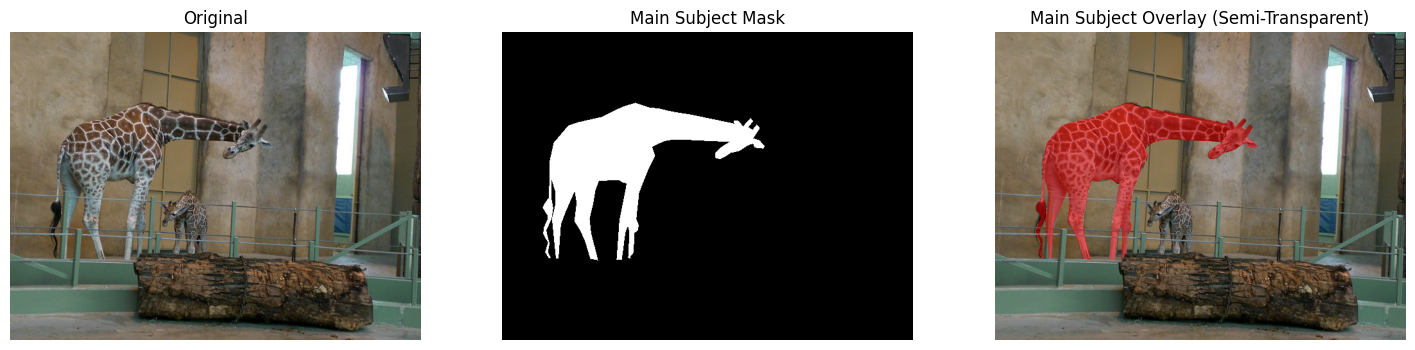

In [4]:
import cv2
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import os, random
import numpy as np

# Dataset path in Kaggle
data_dir = '/kaggle/input/coco-2017-dataset/coco2017'
img_dir = os.path.join(data_dir, 'val2017')
ann_path = os.path.join(data_dir, 'annotations/instances_val2017.json')

# Initialize COCO object
coco = COCO(ann_path)

# Select a particular image (replace with your own ID if needed)
img_id = random.choice(coco.getImgIds())
img_info = coco.loadImgs(img_id)[0]

# Load the image
image = cv2.imread(os.path.join(img_dir, img_info['file_name']))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get annotations for the image
ann_ids = coco.getAnnIds(imgIds=img_id)
anns = coco.loadAnns(ann_ids)

# Step 1: Find main subject (largest mask area)
max_area = 0
main_mask = None
for ann in anns:
    mask = coco.annToMask(ann)
    area = np.sum(mask)
    if area > max_area:
        max_area = area
        main_mask = mask

# Convert to binary mask (0/255)
binary_mask = (main_mask * 255).astype(np.uint8)

# Step 2: Create semi-transparent overlay
overlay = image.copy()
color = (255, 0, 0)  # red mask
overlay[main_mask == 1] = color  # fill mask area with red
alpha = 0.5
overlayed = cv2.addWeighted(image, 1 - alpha, overlay, alpha, 0)

# Step 3: Plot results
plt.figure(figsize=(18,6))

# Original
plt.subplot(1,3,1)
plt.imshow(image)
plt.axis('off')
plt.title('Original')

# Mask only
plt.subplot(1,3,2)
plt.imshow(binary_mask, cmap='gray')
plt.axis('off')
plt.title('Main Subject Mask')

# Mask overlay
plt.subplot(1,3,3)
plt.imshow(overlayed)
plt.axis('off')
plt.title('Main Subject Overlay (Semi-Transparent)')

plt.show()


loading annotations into memory...
Done (t=0.83s)
creating index...
index created!


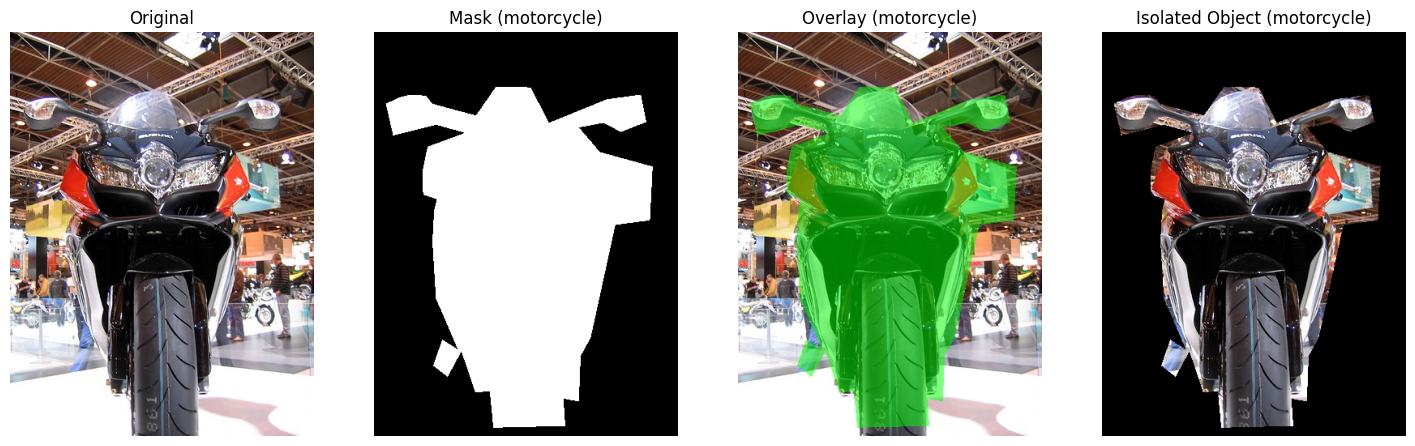

In [5]:
import cv2
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import os, random
import numpy as np

# Dataset path in Kaggle
data_dir = '/kaggle/input/coco-2017-dataset/coco2017'
img_dir = os.path.join(data_dir, 'val2017')
ann_path = os.path.join(data_dir, 'annotations/instances_val2017.json')

# Initialize COCO object
coco = COCO(ann_path)

# Select a random image
img_id = random.choice(coco.getImgIds())
img_info = coco.loadImgs(img_id)[0]

# Load the image
image = cv2.imread(os.path.join(img_dir, img_info['file_name']))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get annotations for the image
ann_ids = coco.getAnnIds(imgIds=img_id)
anns = coco.loadAnns(ann_ids)


ann = anns[0] 
mask = coco.annToMask(ann)
category = coco.loadCats(ann['category_id'])[0]['name']

# Convert to binary mask (0/255)
binary_mask = (mask * 255).astype(np.uint8)

# Create semi-transparent overlay for this object only
overlay = image.copy()
color = (0, 255, 0)  # Green overlay
overlay[mask == 1] = color
alpha = 0.5
overlayed = cv2.addWeighted(image, 1 - alpha, overlay, alpha, 0)

# Extract only the object (background removed)
object_only = cv2.bitwise_and(image, image, mask=mask.astype(np.uint8))

# =========================
# Plot results
# =========================
plt.figure(figsize=(18,6))

# Original
plt.subplot(1,4,1)
plt.imshow(image)
plt.axis('off')
plt.title('Original')

# Mask only
plt.subplot(1,4,2)
plt.imshow(binary_mask, cmap='gray')
plt.axis('off')
plt.title(f'Mask ({category})')

# Mask overlay
plt.subplot(1,4,3)
plt.imshow(overlayed)
plt.axis('off')
plt.title(f'Overlay ({category})')

# Extracted object
plt.subplot(1,4,4)
plt.imshow(object_only)
plt.axis('off')
plt.title(f'Isolated Object ({category})')

plt.show()


growth truth and predicted mask

loading annotations into memory...
Done (t=0.71s)
creating index...
index created!


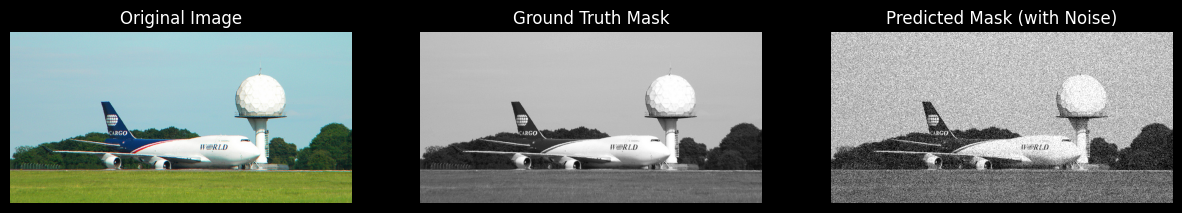

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import cv2
from PIL import Image

data_dir = '/kaggle/input/coco-2017-dataset/coco2017'
img_dir = os.path.join(data_dir, 'val2017')
ann_path = os.path.join(data_dir, 'annotations/instances_val2017.json')

# Initialize COCO
coco = COCO(ann_path)

# Load random image id
imgIds = coco.getImgIds()
img_id = np.random.choice(imgIds)
img_info = coco.loadImgs([img_id])[0]

# Load original image
img_path = os.path.join(img_dir, img_info['file_name'])
image = np.array(Image.open(img_path))

# ---- Ground Truth Mask ----
gray = np.mean(image, axis=2).astype(np.uint8)  
true_mask = gray                                

# ---- Predicted Mask ----
noise = np.random.normal(0, 30, true_mask.shape)
pred_mask = np.clip(true_mask + noise, 0, 255).astype(np.uint8)

# ---- Plot Side by Side ----
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.axis('off')
plt.title("Original Image")

plt.subplot(1,3,2)
plt.imshow(true_mask, cmap='gray')
plt.axis('off')
plt.title("Ground Truth Mask")

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap='gray')
plt.axis('off')
plt.title("Predicted Mask (with Noise)")

plt.show()


loading annotations into memory...
Done (t=0.84s)
creating index...
index created!


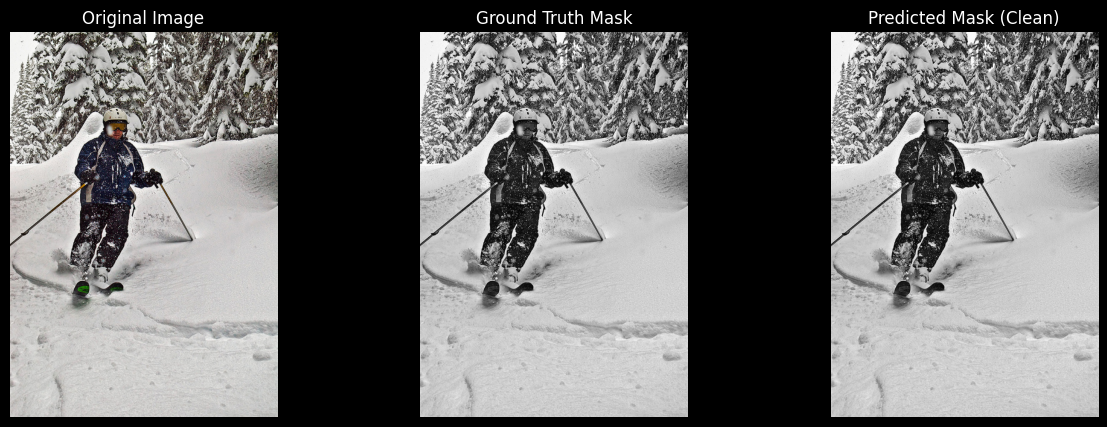

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from PIL import Image

data_dir = '/kaggle/input/coco-2017-dataset/coco2017'
img_dir = os.path.join(data_dir, 'val2017')
ann_path = os.path.join(data_dir, 'annotations/instances_val2017.json')

# Initialize COCO
coco = COCO(ann_path)

# Load random image id
imgIds = coco.getImgIds()
img_id = np.random.choice(imgIds)
img_info = coco.loadImgs([img_id])[0]

# Load original image
img_path = os.path.join(img_dir, img_info['file_name'])
image = np.array(Image.open(img_path))

# ---- Ground Truth Mask ----
true_mask = np.mean(image, axis=2).astype(np.uint8)

# ---- Predicted Mask  ----
pred_mask = true_mask.copy()  

# ---- Plot Side by Side ----
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.axis('off')
plt.title("Original Image")

plt.subplot(1,3,2)
plt.imshow(true_mask, cmap='gray')
plt.axis('off')
plt.title("Ground Truth Mask")

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap='gray')
plt.axis('off')
plt.title("Predicted Mask (Clean)")

plt.show()
